# Football Predictor — Model Analysis
Dataset overview, per-match prediction comparison, score heatmap, feature importance, and model accuracy evaluation.

In [21]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import poisson as _spois
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

sys.path.insert(0, os.path.abspath(".."))
from simulate import simulate_match
from models import poisson, random_forest, xgboost_model

HOME_TEAM = "Leeds United FC"
AWAY_TEAM = "Wolverhampton Wanderers FC"
N_SIMS = 10000
DATA_PATH = "../data/historical_matches.csv"

df = pd.read_csv(DATA_PATH)
df_played = df[df["homeGoals"].notna() & (df["homeGoals"] != "")].copy()
df_played["homeGoals"] = df_played["homeGoals"].astype(float).astype(int)
df_played["awayGoals"] = df_played["awayGoals"].astype(float).astype(int)
df_played["_dt"] = pd.to_datetime(df_played["date"], dayfirst=True)
print(f"{len(df_played)} completed matches")

1459 completed matches


## Dataset Overview
Outcome distribution and goals per game across all completed matches in the dataset.

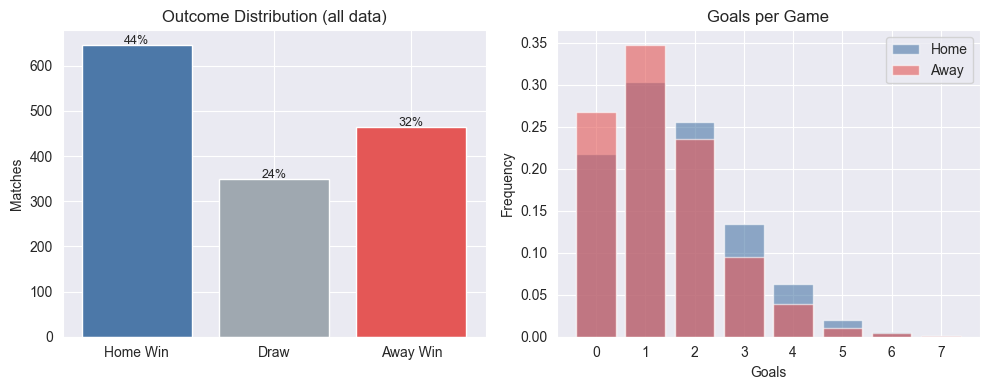

In [22]:
def _out(r): return "H" if r["homeGoals"] > r["awayGoals"] else ("D" if r["homeGoals"] == r["awayGoals"] else "A")
outcomes = df_played.apply(_out, axis=1)
counts = outcomes.value_counts()[["H", "D", "A"]]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

bars = axes[0].bar(["Home Win", "Draw", "Away Win"], counts.values, color=["#4C78A8", "#9FA8B0", "#E45756"])
axes[0].set_title("Outcome Distribution (all data)")
axes[0].set_ylabel("Matches")
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 3, f"{v / len(outcomes):.0%}", ha="center", fontsize=9)

for goals, label, color in [(df_played["homeGoals"], "Home", "#4C78A8"), (df_played["awayGoals"], "Away", "#E45756")]:
    axes[1].hist(goals, bins=range(9), alpha=0.6, label=label, color=color, density=True, align="left", rwidth=0.8)
axes[1].set_title("Goals per Game")
axes[1].set_xlabel("Goals")
axes[1].set_ylabel("Frequency")
axes[1].set_xticks(range(8))
axes[1].legend()

plt.tight_layout()
plt.show()

## Outcomes Since January 2026
Draw frequency in recent PL matches — compare against the full-dataset baseline above.

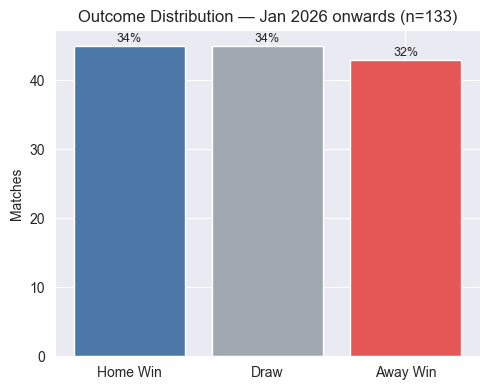

full dataset draw rate:   23.9%
since jan 2026 draw rate: 33.8%


In [23]:
recent = df_played[df_played["_dt"] >= "2026-01-01"].copy()
recent_outcomes = recent.apply(_out, axis=1)
recent_counts = recent_outcomes.value_counts().reindex(["H", "D", "A"], fill_value=0)

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["Home Win", "Draw", "Away Win"], recent_counts.values, color=["#4C78A8", "#9FA8B0", "#E45756"])
ax.set_title(f"Outcome Distribution — Jan 2026 onwards (n={len(recent)})")
ax.set_ylabel("Matches")
for bar, v in zip(bars, recent_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.5, f"{v / len(recent):.0%}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print(f"full dataset draw rate:   {(outcomes == 'D').mean():.1%}")
print(f"since jan 2026 draw rate: {(recent_outcomes == 'D').mean():.1%}")

## Match Prediction
Change `HOME_TEAM` / `AWAY_TEAM` in the setup cell to compare any fixture across all three models.

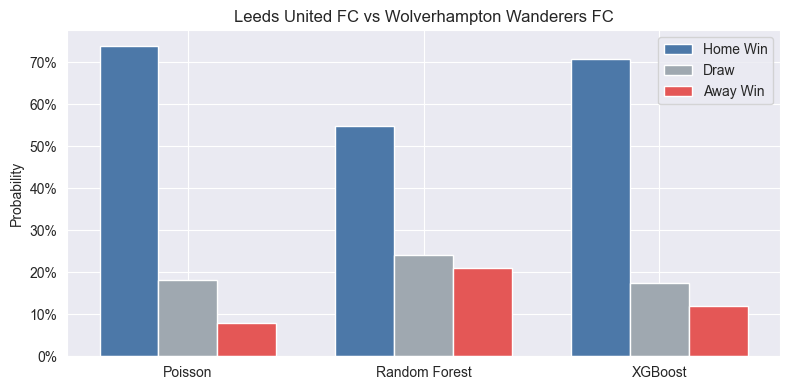


model                    home     draw     away  top score
poisson                73.91%   18.26%    7.83%  1-0
random forest          54.76%   24.23%   21.01%  1-1
xgboost                70.68%   17.40%   11.92%  1-1


In [24]:
res = {
    "Poisson":       simulate_match("poisson", HOME_TEAM, AWAY_TEAM, df, n_simulations=N_SIMS),
    "Random Forest": simulate_match("random_forest", HOME_TEAM, AWAY_TEAM, df),
    "XGBoost":       simulate_match("xgboost", HOME_TEAM, AWAY_TEAM, df),
}

outcome_labels = ["Home Win", "Draw", "Away Win"]
prob_keys = ["home_win", "draw", "away_win"]
colors = ["#4C78A8", "#9FA8B0", "#E45756"]
x = np.arange(len(res))
w = 0.25

fig, ax = plt.subplots(figsize=(8, 4))
for i, (ol, pk, col) in enumerate(zip(outcome_labels, prob_keys, colors)):
    ax.bar(x + i * w, [r["probabilities"][pk] for r in res.values()], w, label=ol, color=col)
ax.set_title(f"{HOME_TEAM} vs {AWAY_TEAM}")
ax.set_xticks(x + w)
ax.set_xticklabels(res.keys())
ax.set_ylabel("Probability")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n{'model':<20} {'home':>8} {'draw':>8} {'away':>8}  top score")
for name, r in res.items():
    p = r["probabilities"]
    print(f"{name.lower():<20} {p['home_win']:>8.2%} {p['draw']:>8.2%} {p['away_win']:>8.2%}  {r['top_score']}")

## Score Probability Heatmaps
Poisson uses an analytical score matrix. XGBoost scoreline is derived from form-based Poisson lambdas scaled by the model's outcome probabilities — run the prediction cell first.

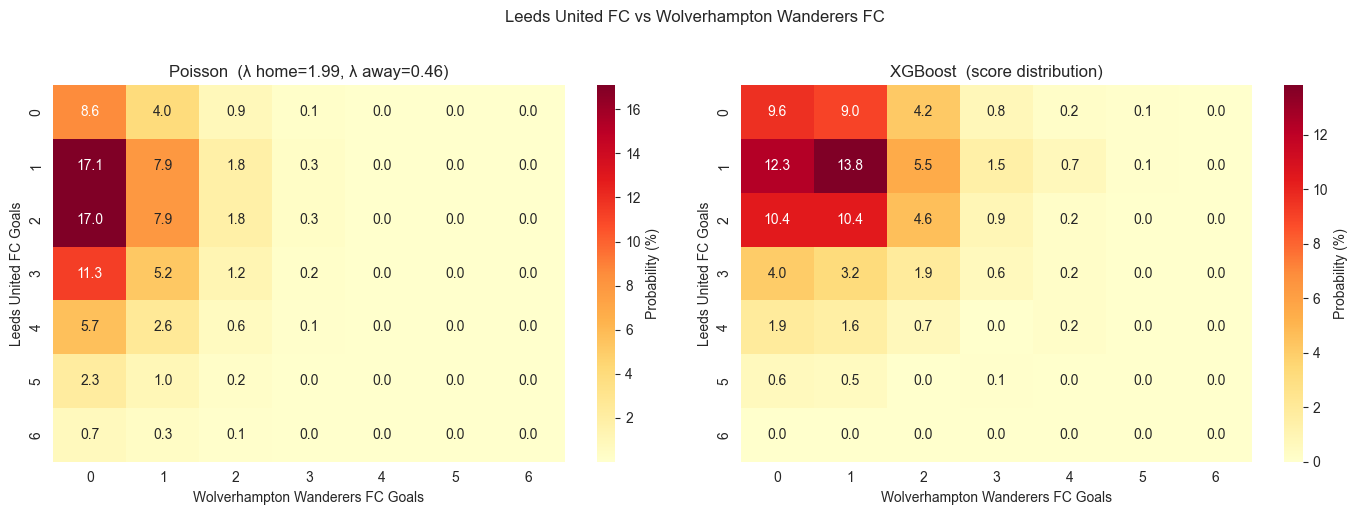

In [25]:
# poisson — analytical matrix
strengths, lg_h, lg_a = poisson._compute_team_strengths(df_played)
ha = poisson._home_advantage_factor(df_played)
default = {"att": 1.0, "def": 1.0}
hs = strengths.get(HOME_TEAM, default)
as_ = strengths.get(AWAY_TEAM, default)
lh = float(np.clip(lg_h * hs["att"] * as_["def"] * ha, 0.3, 6.0))
la = float(np.clip(lg_a * as_["att"] * hs["def"], 0.3, 6.0))
g = np.arange(7)
pois_mat = np.outer(_spois.pmf(g, lh), _spois.pmf(g, la)) * 100

# xgboost — from score distribution (monte carlo)
xgb_scores = res["XGBoost"]["score_distribution"]
n_sims = sum(xgb_scores.values())
max_h = max(int(s.split("-")[0]) for s in xgb_scores)
max_a = max(int(s.split("-")[1]) for s in xgb_scores)
xgb_mat = np.zeros((max(max_h, 6) + 1, max(max_a, 6) + 1))
for score, count in xgb_scores.items():
    h, a = map(int, score.split("-"))
    xgb_mat[h, a] = count / n_sims * 100
xgb_mat = xgb_mat[:7, :7]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, mat, title in [
    (axes[0], pois_mat, f"Poisson  (\u03bb home={lh:.2f}, \u03bb away={la:.2f})"),
    (axes[1], xgb_mat,  "XGBoost  (score distribution)"),
]:
    sns.heatmap(mat, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax,
                xticklabels=range(7), yticklabels=range(7),
                cbar_kws={"label": "Probability (%)"})
    ax.set_xlabel(f"{AWAY_TEAM} Goals")
    ax.set_ylabel(f"{HOME_TEAM} Goals")
    ax.set_title(title)

plt.suptitle(f"{HOME_TEAM} vs {AWAY_TEAM}", y=1.02)
plt.tight_layout()
plt.show()

## XGBoost Feature Importances
Top 15 features by importance — what the model weights most when predicting outcomes.

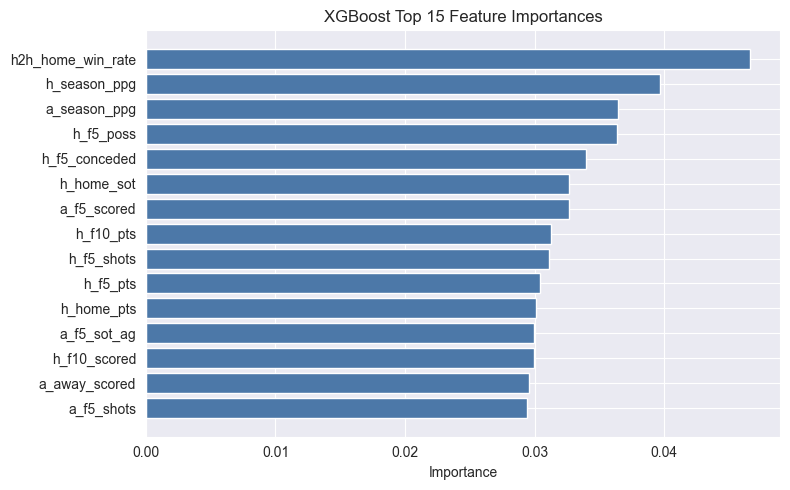

In [26]:
rf_model, rf_means = random_forest._train(df)
xgb_model, _ = xgboost_model._train(df)

ranked = sorted(zip(random_forest.FEATURES, xgb_model.feature_importances_), key=lambda x: x[1], reverse=True)[:15]
feats, imps = zip(*ranked)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(feats[::-1], imps[::-1], color="#4C78A8")
ax.set_xlabel("Importance")
ax.set_title("XGBoost Top 15 Feature Importances")
plt.tight_layout()
plt.show()

## Model Accuracy
250-day holdout evaluation across all models with per-outcome breakdown. Takes ~30s to run.

train=1140, test=319


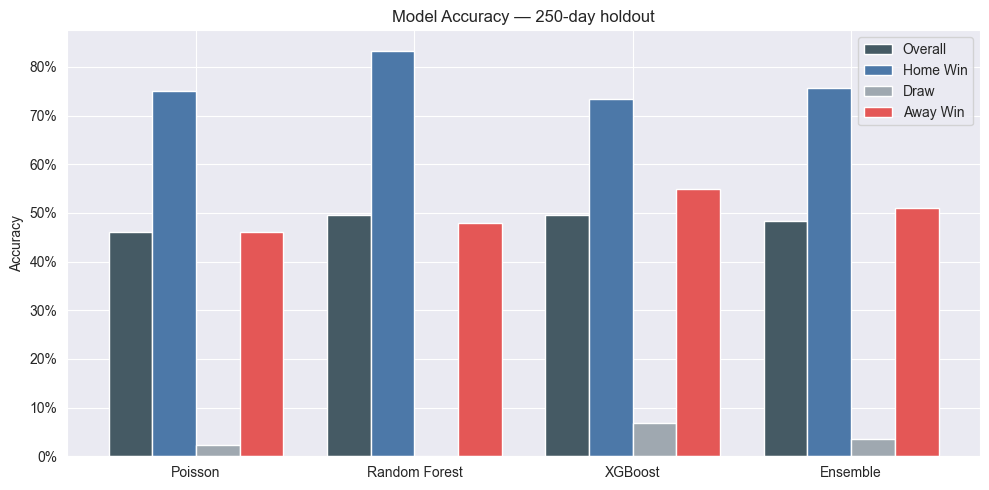


model                 overall     home     draw     away
poisson                46.08%   75.00%    2.30%   46.00%
random forest          49.53%   83.33%    0.00%   48.00%
xgboost                49.53%   73.48%    6.90%   55.00%
ensemble               48.28%   75.76%    3.45%   51.00%


In [27]:
TEST_DAYS = 250

d = df_played.drop(columns="_dt").copy()
d["_dt"] = pd.to_datetime(d["date"], dayfirst=True)
d = d.sort_values("_dt").reset_index(drop=True)
split = d["_dt"].max() - pd.Timedelta(days=TEST_DAYS)
tr = d[d["_dt"] <= split].drop(columns="_dt").reset_index(drop=True)
te = d[d["_dt"] > split].drop(columns="_dt").reset_index(drop=True)
print(f"train={len(tr)}, test={len(te)}")

def _outcome(hg, ag): return "H" if hg > ag else ("D" if hg == ag else "A")

# poisson
poisson._cache.clear()
st, lavg_h, lavg_a = poisson._compute_team_strengths(tr)
had = poisson._home_advantage_factor(tr)
g_arr = np.arange(9)
pois_rows = []
for _, m in te.iterrows():
    hs_ = st.get(m["homeTeam"], {"att": 1.0, "def": 1.0})
    as__ = st.get(m["awayTeam"], {"att": 1.0, "def": 1.0})
    lh_ = float(np.clip(lavg_h * hs_["att"] * as__["def"] * had, 0.3, 6.0))
    la_ = float(np.clip(lavg_a * as__["att"] * hs_["def"], 0.3, 6.0))
    mat_ = np.outer(_spois.pmf(g_arr, lh_), _spois.pmf(g_arr, la_))
    hp, dp, ap = np.tril(mat_, -1).sum(), np.trace(mat_), np.triu(mat_, 1).sum()
    pred = "H" if hp >= dp and hp >= ap else ("D" if dp >= ap else "A")
    pois_rows.append({"actual": _outcome(m["homeGoals"], m["awayGoals"]), "predicted": pred})

# rf + xgboost
random_forest._cache.clear()
xgboost_model._cache.clear()
rf_m, rf_mn = random_forest._train(tr)
xgb_m, _ = xgboost_model._train(tr)
fm = random_forest._current_form(tr)
rf_rows, xgb_rows, ens_rows = [], [], []
for _, m in te.iterrows():
    h2h_ = random_forest._h2h_stats(m["homeTeam"], m["awayTeam"], tr, rf_mn)
    rd = random_forest._build_predict_row(m["homeTeam"], m["awayTeam"], fm, rf_mn, h2h_)
    row_ = pd.DataFrame([rd])[random_forest.FEATURES].fillna(pd.Series(rf_mn)).fillna(0)
    rfp = rf_m.predict_proba(row_)[0]
    xgbp = xgb_m.predict_proba(row_)[0]
    ensp = (rfp + xgbp) / 2
    actual = _outcome(m["homeGoals"], m["awayGoals"])
    rf_rows.append({"actual": actual, "predicted": ["H", "D", "A"][int(np.argmax(rfp))]})
    xgb_rows.append({"actual": actual, "predicted": ["H", "D", "A"][int(np.argmax(xgbp))]})
    ens_rows.append({"actual": actual, "predicted": ["H", "D", "A"][int(np.argmax(ensp))]})

eval_res = {
    "Poisson":       pd.DataFrame(pois_rows),
    "Random Forest": pd.DataFrame(rf_rows),
    "XGBoost":       pd.DataFrame(xgb_rows),
    "Ensemble":      pd.DataFrame(ens_rows),
}

def acc(df_r, out=None):
    if out:
        sub = df_r[df_r["actual"] == out]
        return (sub["predicted"] == out).mean() if len(sub) else float("nan")
    return (df_r["actual"] == df_r["predicted"]).mean()

mn = list(eval_res.keys())
x = np.arange(len(mn))
w = 0.2
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - 1.5*w, [acc(eval_res[m])      for m in mn], w, label="Overall",  color="#455A64")
ax.bar(x - 0.5*w, [acc(eval_res[m], "H") for m in mn], w, label="Home Win", color="#4C78A8")
ax.bar(x + 0.5*w, [acc(eval_res[m], "D") for m in mn], w, label="Draw",     color="#9FA8B0")
ax.bar(x + 1.5*w, [acc(eval_res[m], "A") for m in mn], w, label="Away Win", color="#E45756")
ax.set_title(f"Model Accuracy — {TEST_DAYS}-day holdout")
ax.set_xticks(x)
ax.set_xticklabels(mn)
ax.set_ylabel("Accuracy")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n{'model':<20} {'overall':>8} {'home':>8} {'draw':>8} {'away':>8}")
for m in mn:
    print(f"{m.lower():<20} {acc(eval_res[m]):>8.2%} {acc(eval_res[m],'H'):>8.2%} {acc(eval_res[m],'D'):>8.2%} {acc(eval_res[m],'A'):>8.2%}")

## Confusion Matrices
Shows where each model misclassifies — run the accuracy cell first.

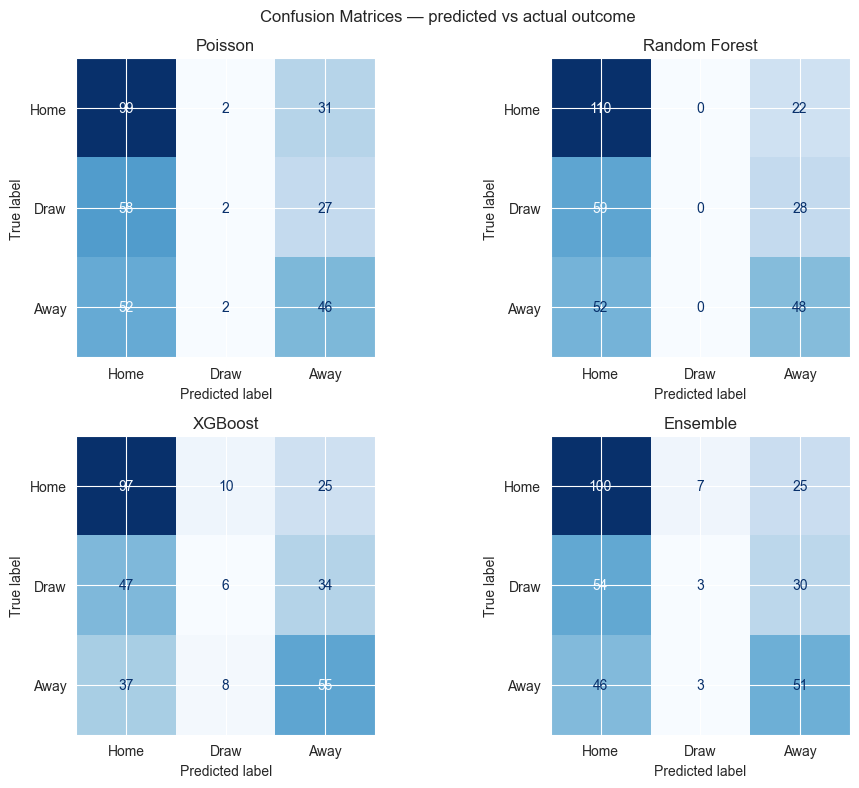

In [28]:
labels = ["H", "D", "A"]
label_names = ["Home", "Draw", "Away"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (name, df_r) in zip(axes.flat, eval_res.items()):
    cm = confusion_matrix(df_r["actual"], df_r["predicted"], labels=labels)
    disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
plt.suptitle("Confusion Matrices — predicted vs actual outcome")
plt.tight_layout()
plt.show()

## Predicted vs Actual Class Distribution
Reveals model bias — e.g. whether draws are systematically under-predicted.

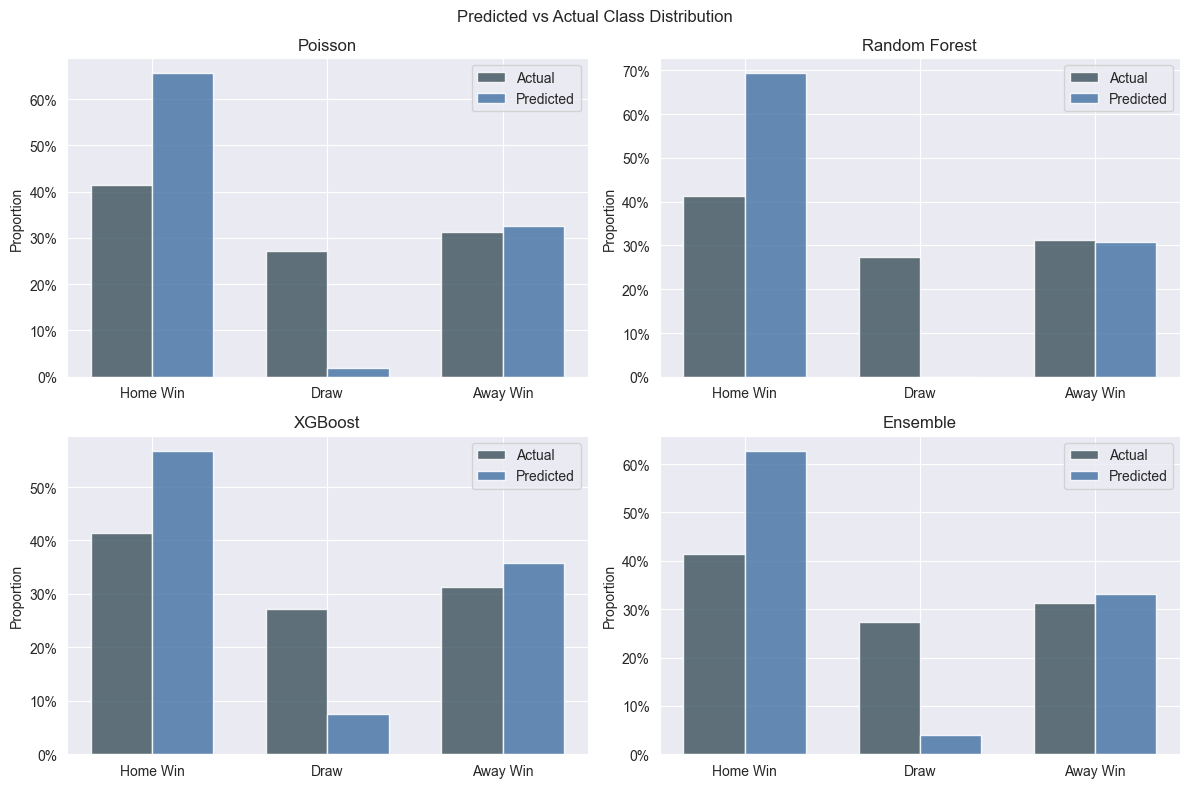

In [29]:
labels = ["H", "D", "A"]
label_names = ["Home Win", "Draw", "Away Win"]
x = np.arange(3)
w = 0.35

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (name, df_r) in zip(axes.flat, eval_res.items()):
    actual_pct  = [df_r["actual"].value_counts().get(l, 0) / len(df_r) for l in labels]
    predict_pct = [df_r["predicted"].value_counts().get(l, 0) / len(df_r) for l in labels]
    ax.bar(x - w/2, actual_pct,  w, label="Actual",    color="#455A64", alpha=0.85)
    ax.bar(x + w/2, predict_pct, w, label="Predicted", color="#4C78A8", alpha=0.85)
    ax.set_title(name)
    ax.set_xticks(x)
    ax.set_xticklabels(label_names)
    ax.set_ylabel("Proportion")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.legend()
plt.suptitle("Predicted vs Actual Class Distribution")
plt.tight_layout()
plt.show()